# Variational Autoencoder

Based on [post](https://learnopencv.com/variational-autoencoder-in-tensorflow/) from Aditya Sharma.

Code on github [here](https://github.com/spmallick/learnopencv/tree/master/Variational-Autoencoder-TensorFlow)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import time
import tensorflow as tf
from pathlib import Path
from tensorflow import keras
from tensorflow.keras import layers
from IPython import display

In [3]:
print(tf.__version__)
print(keras.__version__)

2.17.0
3.6.0


# Autoencoder:

Selfsupervised Learning

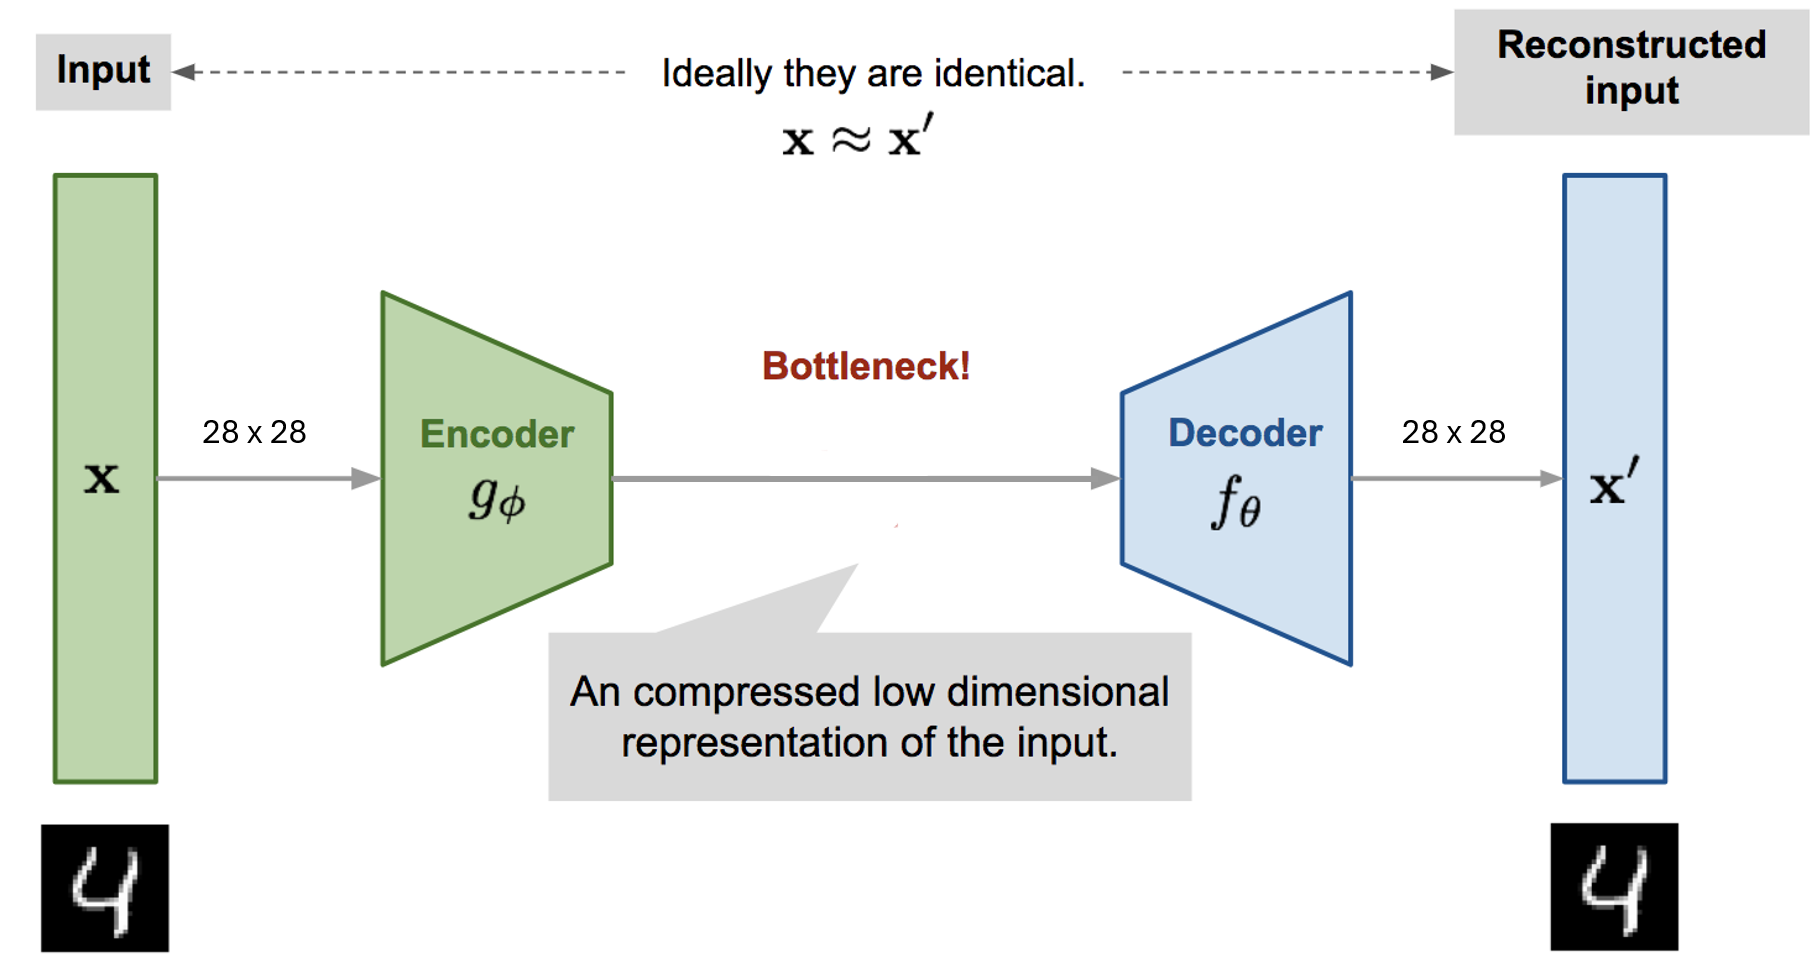

# Variational Autoencoder

Variant, with random variable at the bottleneck for smoother predictions.

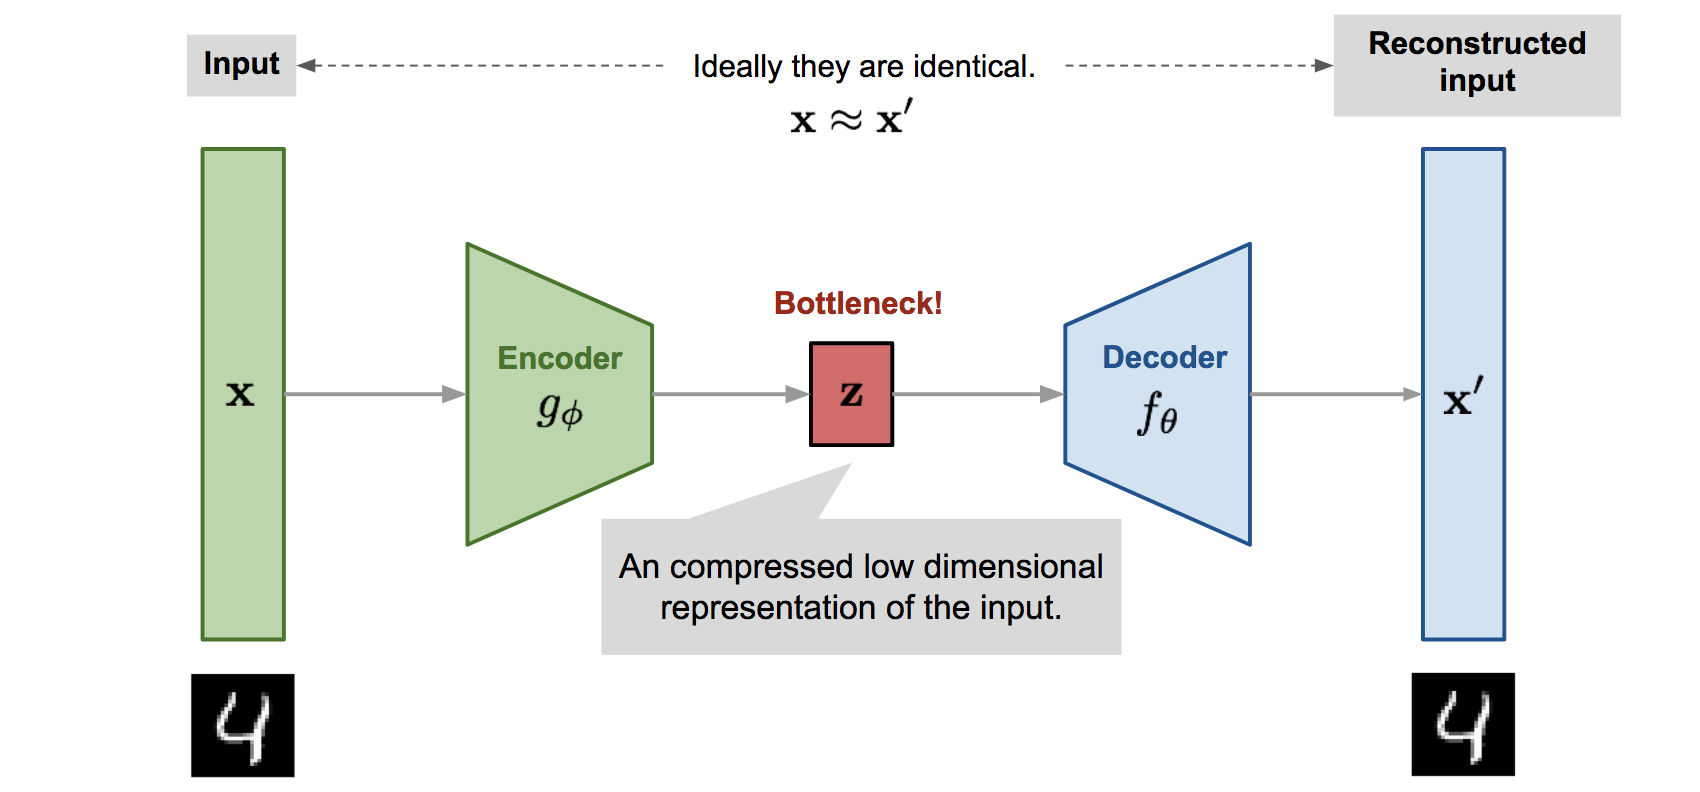

## Load data and preprocess

In [12]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1).astype('float32')
x_test = x_test.reshape(x_test.shape[0], 28, 28, 1).astype('float32')
print(x_train.shape, x_test.shape)

# Batch and shuffle the data
batch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(batch_size)
test_dataset =  tf.data.Dataset.from_tensor_slices(x_test).shuffle(10000).batch(batch_size)

(60000, 28, 28, 1) (10000, 28, 28, 1)


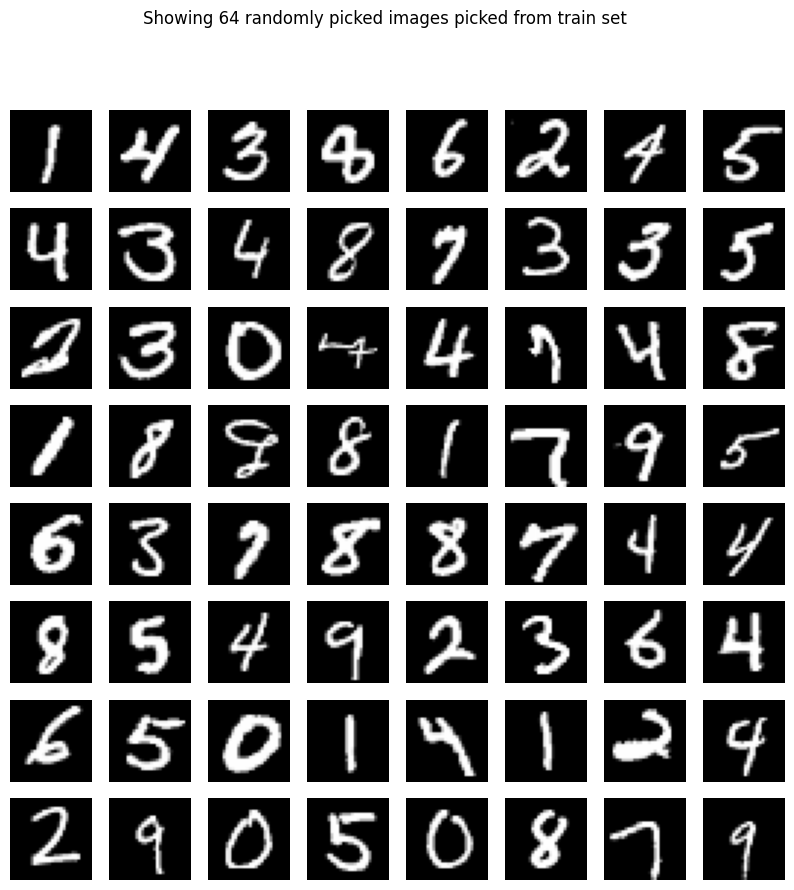

In [13]:
#View a few images
n = 8
idxs = np.random.choice(x_train.shape[0], n * n)
fig, axs = plt.subplots(n, n, figsize = (10,10))
for r, rows in enumerate(axs):
    for c, ax in enumerate(rows):
        ax.imshow(x_train[idxs[r * n + c], :, :, 0], cmap='Greys_r')
        ax.set_axis_off()
plt.suptitle(f"Showing {n*n} randomly picked images picked from train set")
plt.show();

Instead of normalizing by changing the dataset, we will use a normalisation layer in the model

In [14]:
normalization_layer = layers.Rescaling(scale= 1./255)

Showing what it does

In [15]:
normalized_ds = train_dataset.map(lambda x: normalization_layer(x))
image_batch = next(iter(normalized_ds))
first_image = image_batch[0]
image_batch.shape
image_batch[0, 10:15, 10:15, 0]

<tf.Tensor: shape=(5, 5), dtype=float32, numpy=
array([[0.9960785 , 0.3372549 , 0.        , 0.17254902, 0.8862746 ],
       [0.7372549 , 0.00392157, 0.        , 0.        , 0.46274513],
       [0.3137255 , 0.        , 0.        , 0.        , 0.3647059 ],
       [0.3137255 , 0.        , 0.        , 0.        , 0.47450984],
       [0.5921569 , 0.00392157, 0.        , 0.12156864, 0.7137255 ]],
      dtype=float32)>

In [ ]:
input_encoder = (28, 28, 1)  # shape of the image, as input of the VAE


input_decoder = (2,)         # shape of the bottleneck, a.k.a. the latent space, as input of the decoder

## Build model

### Build encoder

In [17]:
def encoder(input_encoder):
    
    inputs = keras.Input(shape=input_encoder, name='input_layer')
    
    x = layers.Conv2D(32, kernel_size=3, strides=1, padding='same', name='conv_1')(inputs)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.LeakyReLU(name='lrelu_1')(x)
    
    x = layers.Conv2D(64, kernel_size=3, strides=2, padding='same', name='conv_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.LeakyReLU(name='lrelu_2')(x)
        
    x = layers.Conv2D(64, 3, 2, padding='same', name='conv_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.LeakyReLU(name='lrelu_3')(x)

    x = layers.Conv2D(64, 3, 1, padding='same', name='conv_4')(x)
    x = layers.BatchNormalization(name='bn_4')(x)
    x = layers.LeakyReLU(name='lrelu_4')(x)

    flatten = layers.Flatten()(x)

    mean = layers.Dense(2, name='mean')(flatten)
    log_var = layers.Dense(2, name='log_var')(flatten)

    model = tf.keras.Model(inputs, (mean, log_var), name="Encoder")
    
    return model

In [18]:
enc = encoder(input_encoder)

In [20]:
enc.summary()

Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_1 (Conv2D)     │ (None, 28, 28,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_1                │ (None, 28, 28,    │        128 │ conv_1[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lrelu_1 (LeakyReLU) │ (None, 28, 28,    │          0 │ bn_1[0][0]        │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_2 (Conv2D)     │ (None, 14, 14,    │     18,496 │ lrelu_1[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_2                │ (None, 14, 14,    │        256 │ conv_2[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lrelu_2 (LeakyReLU) │ (None, 14, 14,    │          0 │ bn_2[0][0]        │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_3 (Conv2D)     │ (None, 7, 7, 64)  │     36,928 │ lrelu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_3                │ (None, 7, 7, 64)  │        256 │ conv_3[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lrelu_3 (LeakyReLU) │ (None, 7, 7, 64)  │          0 │ bn_3[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_4 (Conv2D)     │ (None, 7, 7, 64)  │     36,928 │ lrelu_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_4                │ (None, 7, 7, 64)  │        256 │ conv_4[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lrelu_4 (LeakyReLU) │ (None, 7, 7, 64)  │          0 │ bn_4[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ lrelu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mean (Dense)        │ (None, 2)         │      6,274 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ log_var (Dense)     │ (None, 2)         │      6,274 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 106,116 (414.52 KB)

 Trainable params: 105,668 (412.77 KB)

 Non-trainable params: 448 (1.75 KB)

In [21]:
enc.output

(<KerasTensor shape=(None, 2), dtype=float32, sparse=False, name=keras_tensor_13>,
 <KerasTensor shape=(None, 2), dtype=float32, sparse=False, name=keras_tensor_14>)

In [22]:
# enc.save_weights('vae-enc.weights.h5')

### Build stochastic latent vector sampling layer

In [23]:
class Sampling(layers.Layer):
    """Reparameterization trick: sample z from N(mean, exp(log_var))."""
    
    def call(self, inputs):
        mean, log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(mean), mean=0.0, stddev=1.0)
        return mean + tf.exp(log_var * 0.5) * epsilon

In [24]:
input_1 = (2,)
input_2 = (2,)

In [25]:
def sampling(input_1, input_2):
    """Build a small model that exposes the stochastic sampling layer."""
    mean = keras.Input(shape=input_1, name='input_layer_mean')
    log_var = keras.Input(shape=input_2, name='input_layer_log_var')
    out = Sampling(name='encoder_output')([mean, log_var])
    sampler = tf.keras.Model([mean, log_var], out, name="Sampler")
    return sampler

In [26]:
# final = sampling(input_1,input_2)
sampler = sampling(input_1,input_2)

In [27]:
sampler.summary()
assert sampler.output.shape[1] == input_decoder[0]

Model: "Sampler"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_mean    │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_log_var │ (None, 2)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_output      │ (None, 2)         │          0 │ input_layer_mean… │
│ (Sampling)          │                   │            │ input_layer_log_… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [28]:
sampler.output

<KerasTensor shape=(None, 2), dtype=float32, sparse=False, name=keras_tensor_15>

In [20]:
# sampler.save('sampling.keras')

### Build decoder

In [29]:
def decoder(input_decoder):
    
    inputs = keras.Input(shape=input_decoder, name='input_layer')

    # output for the Dense layer must be compatible with the first conv shape, 
    # i.e. the last encoder conv: (7, 7, 64). 7 * 7 * 64 = 3136
    x = layers.Dense(3136, name='dense_1')(inputs)
    x = layers.Reshape((7, 7, 64), name='Reshape_Layer')(x)
   
    # Block-1
    x = layers.Conv2DTranspose(64, 3, strides= 1, padding='same',name='conv_transpose_1')(x)
    x = layers.BatchNormalization(name='bn_1')(x)
    x = layers.LeakyReLU(name='lrelu_1')(x)
  
    # Block-2
    x = layers.Conv2DTranspose(64, 3, strides= 2, padding='same', name='conv_transpose_2')(x)
    x = layers.BatchNormalization(name='bn_2')(x)
    x = layers.LeakyReLU(name='lrelu_2')(x)
    
    # Block-3
    x = layers.Conv2DTranspose(32, 3, 2, padding='same', name='conv_transpose_3')(x)
    x = layers.BatchNormalization(name='bn_3')(x)
    x = layers.LeakyReLU(name='lrelu_3')(x)
    
    # Block-4
    # Using sigmoid as activation to force pixel values to be between 0 and 1
    outputs = layers.Conv2DTranspose(1, 3, 1,padding='same', activation='sigmoid', name='conv_transpose_4')(x)

    model = tf.keras.Model(inputs, outputs, name="Decoder")
    return model

In [30]:
dec = decoder(input_decoder)
dec.summary()
assert dec.output.shape[1:] == (28, 28, 1), f"Output shape {dec.output.get_shape()} not compatible with image size"

Model: "Decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Reshape_Layer (Reshape)         │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_1                │ (None, 7, 7, 64)       │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 7, 7, 64)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu_1 (LeakyReLU)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_2                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 14, 14, 64)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu_2 (LeakyReLU)             │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_3                │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 28, 28, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrelu_3 (LeakyReLU)             │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_transpose_4                │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 102,657 (401.00 KB)

 Trainable params: 102,337 (399.75 KB)

 Non-trainable params: 320 (1.25 KB)

In [31]:
dec.output

<KerasTensor shape=(None, 28, 28, 1), dtype=float32, sparse=False, name=keras_tensor_27>

In [23]:
# dec.save_weights('vae-fashion-dec.weights.h5')

### Loss Function

In [32]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)

In [33]:
def mse_loss(y_true, y_pred):
    loss = tf.reduce_mean(tf.square(y_true - y_pred), axis=[1, 2, 3])
    return 1000.0 * loss

def kl_loss(mean, log_var):
    loss = -0.5 * tf.reduce_sum(1.0 + log_var - tf.square(mean) - tf.exp(log_var), axis=1)
    return loss

def vae_loss(y_true, y_pred, mean, log_var):
    rl = mse_loss(y_true, y_pred)
    kll = kl_loss(mean, log_var)
    return rl + kll

### Training Loop

In [34]:
class VAE(keras.Model):
    def __init__(self, encoder, sampler, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.sampler = sampler
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name='loss')
        self.reconstruction_loss_tracker = keras.metrics.Mean(name='reconstruction_loss')
        self.kl_loss_tracker = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs, training=False):
        mean, log_var = self.encoder(inputs, training=training)
        latent = self.sampler([mean, log_var], training=training)
        return self.decoder(latent, training=training)

    def train_step(self, data):
        images = data[0] if isinstance(data, tuple) else data

        with tf.GradientTape() as tape:
            mean, log_var = self.encoder(images, training=True)
            latent = self.sampler([mean, log_var], training=True)
            generated_images = self.decoder(latent, training=True)

            reconstruction = mse_loss(images, generated_images)
            kl = kl_loss(mean, log_var)
            total_loss = tf.reduce_mean(reconstruction + kl)

        trainable_vars = (
            self.encoder.trainable_variables
            + self.sampler.trainable_variables
            + self.decoder.trainable_variables
        )
        gradients = tape.gradient(total_loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(tf.reduce_mean(reconstruction))
        self.kl_loss_tracker.update_state(tf.reduce_mean(kl))

        return {
            'loss': self.total_loss_tracker.result(),
            'reconstruction_loss': self.reconstruction_loss_tracker.result(),
            'kl_loss': self.kl_loss_tracker.result(),
        }

In [35]:
images_dir = Path('tf_vae/mnist/images')
images_dir.mkdir(parents=True, exist_ok=True)

weights_dir = Path('tf_vae/saved/training_weights')
weights_dir.mkdir(parents=True, exist_ok=True)

preview_seed = next(iter(normalized_ds.take(1)))[:25]

In [36]:
vae = VAE(enc, sampler, dec, name='vae_mnist')
vae.compile(optimizer=optimizer)

# Build once so summary is available even before fitting.
vae.build(input_shape=(None, 28, 28, 1))
vae.summary()

Model: "vae_mnist"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Encoder (Functional)            │ [(None, 2), (None, 2)] │       106,116 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Sampler (Functional)            │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder (Functional)            │ (None, 28, 28, 1)      │       102,657 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 208,773 (815.52 KB)

 Trainable params: 208,005 (812.52 KB)

 Non-trainable params: 768 (3.00 KB)

In [37]:
def generate_and_save_images(vae_model, epoch, test_input, output_dir):
    # Run in inference mode for deterministic batch-norm behavior.
    m, v = vae_model.encoder(test_input, training=False)
    latent = vae_model.sampler([m, v], training=False)
    predictions = vae_model.decoder(latent, training=False)

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(5, 5, i + 1)
        plt.imshow(predictions[i, :, :, 0] * 255, cmap='Greys_r')
        plt.axis('off')

    plt.savefig(output_dir / f'image_at_epoch_{epoch:d}.png')
    plt.show()


class VAEProgressCallback(keras.callbacks.Callback):
    def __init__(self, seed_batch, image_dir, ckpt_dir, save_every=20):
        super().__init__()
        self.seed_batch = seed_batch
        self.image_dir = image_dir
        self.ckpt_dir = ckpt_dir
        self.save_every = save_every

    def on_epoch_end(self, epoch, logs=None):
        epoch_id = epoch + 1
        generate_and_save_images(self.model, epoch_id, self.seed_batch, self.image_dir)

        if epoch_id % self.save_every == 0:
            self.model.encoder.save_weights(self.ckpt_dir / f'mnist_enc_epoch_{epoch_id:04d}.weights.h5')
            self.model.decoder.save_weights(self.ckpt_dir / f'mnist_dec_epoch_{epoch_id:04d}.weights.h5')

        if logs is not None:
            print(
                f"Epoch {epoch_id:03d} - loss={logs.get('loss', float('nan')):.4f} "
                f"recon={logs.get('reconstruction_loss', float('nan')):.4f} "
                f"kl={logs.get('kl_loss', float('nan')):.4f}"
            )

        display.clear_output(wait=True)


def train(dataset, epochs):
    callback = VAEProgressCallback(
        seed_batch=preview_seed,
        image_dir=images_dir,
        ckpt_dir=weights_dir,
        save_every=20,
    )
    history = vae.fit(dataset, epochs=epochs, callbacks=[callback], verbose=1)
    generate_and_save_images(vae, epochs, preview_seed, images_dir)
    return history

### Train

235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - kl_loss: 5.5688 - loss: 42.4509 - reconstruction_loss: 36.8821


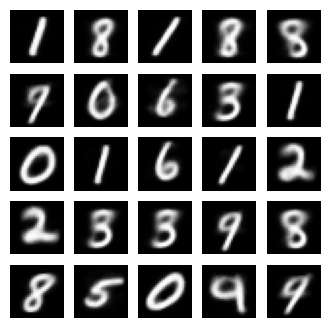

In [39]:
history = train(normalized_ds, 250)

### Technical note (updated)

The notebook previously used a manual loop that accumulated per-batch tensors into NumPy structures, which was brittle and could break when the last batch shape differed.

The training section now uses a custom `keras.Model` with `fit`, metric trackers, and a callback for image snapshots/checkpoints. This removes the old loss-aggregation failure mode and keeps training logic compatible with modern TensorFlow/Keras.

In [43]:
p2drive = weights_dir
p2drive.absolute()

PosixPath('/home/vtec/projects/diyai/utseus-dives/nbs/tf_vae/saved/training_weights')

In [44]:
from datetime import datetime

SAVE_MODEL = False
seed = 'mnist'
stamp = datetime.now().strftime('%y%m%d')

enc_final_path = p2drive / f"{seed}_enc_final_{stamp}.weights.h5"
dec_final_path = p2drive / f"{seed}_dec_final_{stamp}.weights.h5"
vae_final_path = p2drive / f"{seed}_vae_final_{stamp}.keras"

if SAVE_MODEL:
    vae.encoder.save_weights(enc_final_path)
    vae.decoder.save_weights(dec_final_path)
    vae.save(vae_final_path)
    print('Saved:')
    print(f"- {enc_final_path}")
    print(f"- {dec_final_path}")
    print(f"- {vae_final_path}")
else:
    print('If <SAVE_MODEL> is set to True, files will be saved as:')
    print(f"- {enc_final_path.name}")
    print(f"- {dec_final_path.name}")
    print(f"- {vae_final_path.name}")

If <SAVE_MODEL> is set to True, files will be saved as:
- mnist_enc_final_260429.weights.h5
- mnist_dec_final_260429.weights.h5
- mnist_vae_final_260429.keras


In [45]:
latest_enc = sorted(p2drive.glob('mnist_enc_final_*.weights.h5'))
latest_dec = sorted(p2drive.glob('mnist_dec_final_*.weights.h5'))

if latest_enc and latest_dec:
    enc.load_weights(latest_enc[-1])
    dec.load_weights(latest_dec[-1])
    print(f"Loaded encoder: {latest_enc[-1].name}")
    print(f"Loaded decoder: {latest_dec[-1].name}")
else:
    print('No final .weights.h5 files found in training_weights directory.')

Loaded encoder: mnist_enc_final_260429.weights.h5
Loaded decoder: mnist_dec_final_260429.weights.h5


## Explore latent space and reconstruction

###  Latent Space Projection
Latent Space Projection of Variational Autoencoder Trained on Fashion-MNIST

In [ ]:
# embs_np = embeddings.numpy()
# embs_np[np.isinf(embs_np)] = 0
# print(embs_np.max())

In [46]:
cmaps = ['Pastel1', 'Pastel2', 'Paired', 'Accent', 'Dark2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c']
cmap = 'tab10'

def plot_color_bar(cmap, figsize=15):
    gradient = np.linspace(0, 1, 10)
    gradient = np.vstack((gradient, gradient))
    _, ax = plt.subplots(figsize=(figsize,1))
    ax.imshow(gradient, aspect='auto', cmap=plt.get_cmap(cmap))
    # ax.scatter([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], [1, 1, 1, 1, 1, 1, 1, 1, 1, 1], c='#ffffff')
    for i in range(10):
        ax.text(i, .7, str(i), color='#ffffff', fontsize='xx-large', fontweight=1000, horizontalalignment='center')

    ax.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
    ax.set_axis_off()
    plt.show()

# plot_color_bar(cmap)

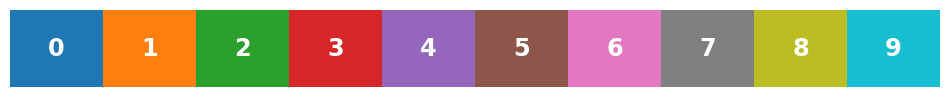

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


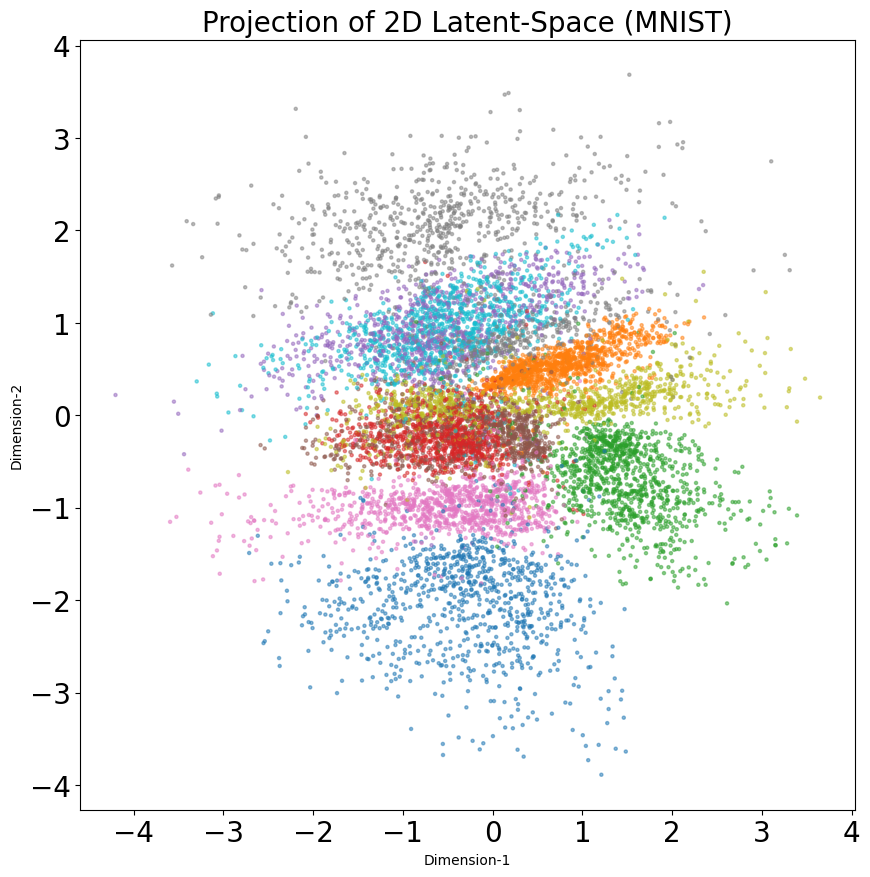

In [47]:
n_to_show = 10_000
figsize = 10

plot_color_bar(cmap, 12)

if x_test.max() > 1.0: x_test = x_test / 255. 

example_idx = np.random.choice(range(len(x_test)), n_to_show)
example_images = np.reshape(x_test[example_idx], (n_to_show, 28, 28, 1))
example_y = np.squeeze(y_test[example_idx])

m, v = enc.predict(example_images)
embeddings = sampler([m,v])

plt.figure(figsize=(figsize, figsize))
plt.scatter(embeddings[:, 0] , embeddings[:, 1], c=example_y, alpha=0.5, s=5, cmap='tab10')
plt.xlabel("Dimension-1", size=10)
plt.ylabel("Dimension-2", size=10)
plt.xticks(size=20)
plt.yticks(size=20)
plt.title("Projection of 2D Latent-Space (MNIST)", size=20)
plt.show()

### Reconstruction
Reconstructing Fashion Images with Latent-Vector Sampled from Normal Distribution

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 585ms/step


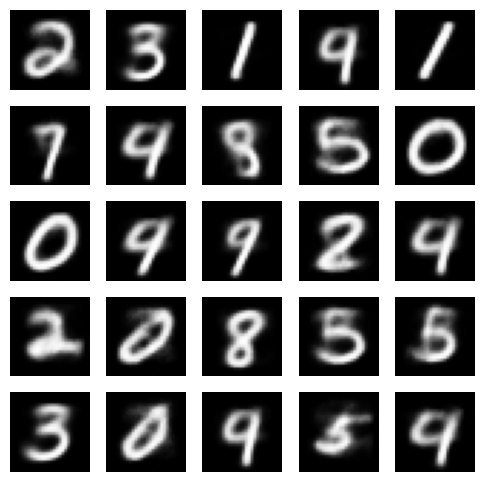

In [48]:
figsize = 6
nbr_latent_vector_samples = 25 # < 25

x = np.random.normal(size=(nbr_latent_vector_samples,2))
#x = np.random.uniform(size=(nbr_latent_vector_samples,200))
# print(x.shape)

reconstruct = dec.predict(x)

fig = plt.figure(figsize=(figsize, figsize))
for i in range(nbr_latent_vector_samples):
    ax = fig.add_subplot(5, 5, i+1)
    ax.axis('off')
    ax.imshow(reconstruct[i, :,:,0]*255, cmap = 'Greys_r')

### Reconstructing Test Images

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


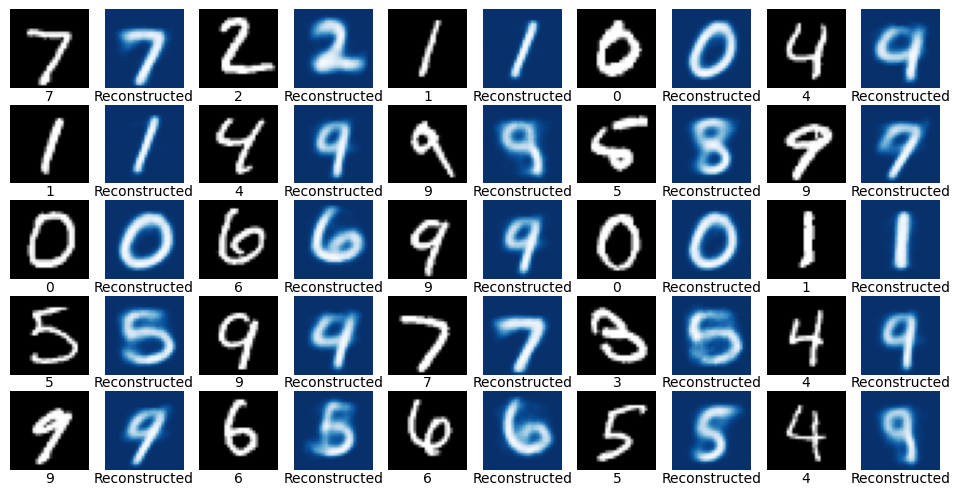

In [49]:
figsize = 6

m, v = enc.predict(x_test[:25])
latent = sampler([m,v])
reconst = dec.predict(latent)

fig = plt.figure(figsize=(figsize * 2, figsize))

for i in range(25):
    ax = fig.add_subplot(5, 5*2, 2*i+1)
    ax.axis('off')
    ax.imshow(x_test[i, :,:,0], cmap = 'Greys_r')
    ax.text(0.5, -0.15, str(y_test[i]), fontsize=10, ha='center', transform=ax.transAxes)
    
    ax = fig.add_subplot(5, 5*2, 2*i+2)
    ax.axis('off')
    ax.text(0.5, -0.15, 'Reconstructed', fontsize=10, ha='center', transform=ax.transAxes)
    ax.imshow(reconst[i, :,:,0]*255, cmap = 'Blues_r')

### Reconstructing uniform samples
Fashion Images with Latent-Vector Sampled Uniformly

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


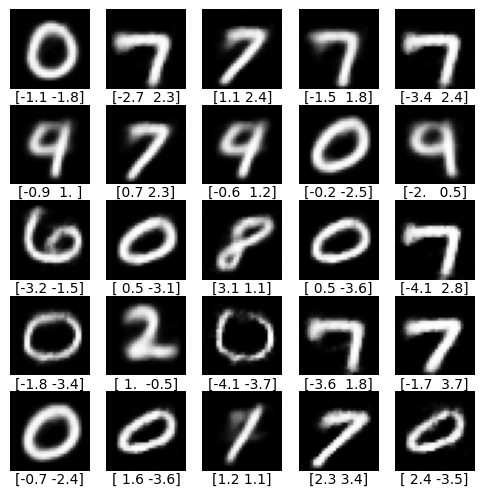

In [50]:
figsize = 6
nbr_latent_vector_samples = 25 # < 25

min_z1 = min(embeddings[:, 0])
max_z1 = max(embeddings[:, 0])
min_z2 = min(embeddings[:, 1])
max_z2 = max(embeddings[:, 1])


z1 = np.random.uniform(min_z1,max_z1, size = (nbr_latent_vector_samples,1))
z2 = np.random.uniform(min_z2,max_z2, size = (nbr_latent_vector_samples,1))
z_grid = np.concatenate((z1, z2), axis=1)
reconst = dec.predict(z_grid)


fig = plt.figure(figsize=(figsize, figsize))

for i in range(nbr_latent_vector_samples):
    ax = fig.add_subplot(5, 5, i+1)
    ax.axis('off')
    ax.text(0.5, -0.15, str(np.round(z_grid[i],1)), fontsize=10, ha='center', transform=ax.transAxes)
    ax.imshow(reconst[i, :,:,0]*255, cmap= 'Greys_r')

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 245ms/step


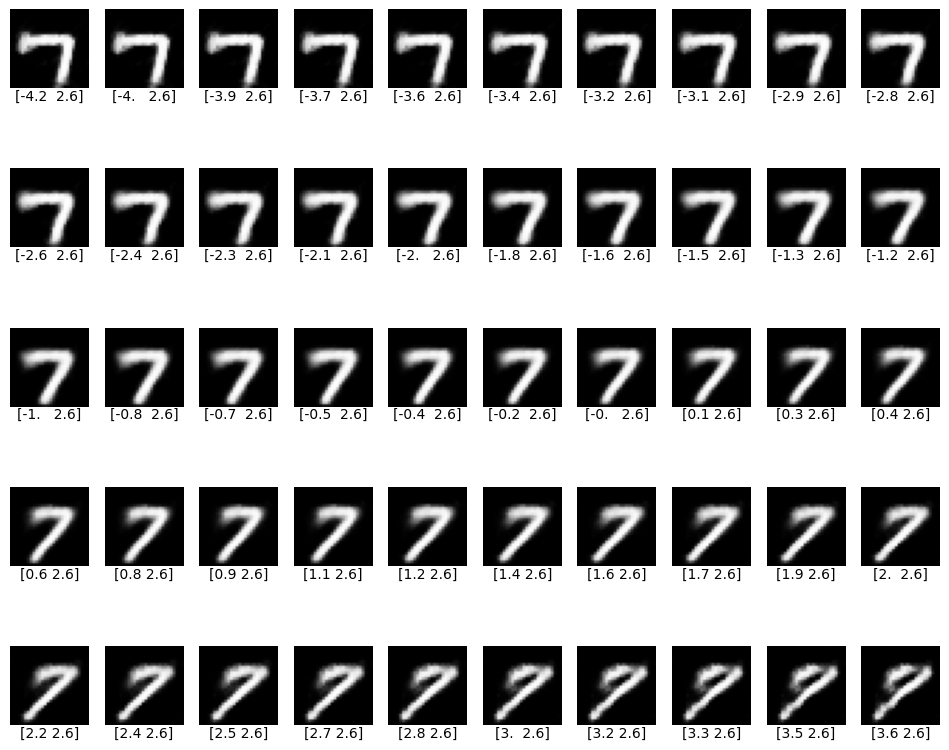

In [51]:
figsize = 12
nbr_latent_vector_samples = 50 # <= 50

z1 = np.reshape(np.linspace(start=min_z1, stop=max_z1, num=nbr_latent_vector_samples), (nbr_latent_vector_samples, 1))
z2 = np.ones_like(z1) * 2.6

z_grid = np.concatenate((z1, z2), axis=1)
reconst = dec.predict(z_grid)

fig = plt.figure(figsize=(figsize, 10))
for i in range(nbr_latent_vector_samples):
    ax = fig.add_subplot(5, 10, i+1)
    ax.axis('off')
    ax.text(0.5, -0.15, str(np.round(z_grid[i],1)), fontsize=10, ha='center', transform=ax.transAxes)
    
    ax.imshow(reconst[i, :,:,0]*255, cmap='Greys_r')

### Reconstruct on a grid
Reconstruct images from latent vectors positioned on a regular grid in the latent space

In [52]:
n = 30
z1 = np.reshape(np.linspace(start=min_z1, stop=max_z1, num=n), (n, 1))
z2 = np.reshape(np.linspace(start=min_z2, stop=max_z2, num=n), (n, 1))

zz1, zz2 = np.meshgrid(z1, z2)

# fig, ax = plt.subplots(figsize=(5,5))
# ax.scatter(zz1, zz2, s=1, alpha=0.5)
# plt.show();

zz1_f = np.reshape(zz1, (n*n, 1))
zz2_f = np.reshape(zz2, (n*n, 1))

# fig, ax = plt.subplots(figsize=(5,5))
# ax.scatter(zz1_f, zz2_f, s=1, alpha=0.5)
# plt.show();

In [53]:
z_grid = np.concatenate((zz1_f, zz2_f), axis=1)
reconst = dec.predict(z_grid)
reconst.shape

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step


(900, 28, 28, 1)

Showing 900 reconstructed images from latent vectors positioned on a regular grid in the latent space


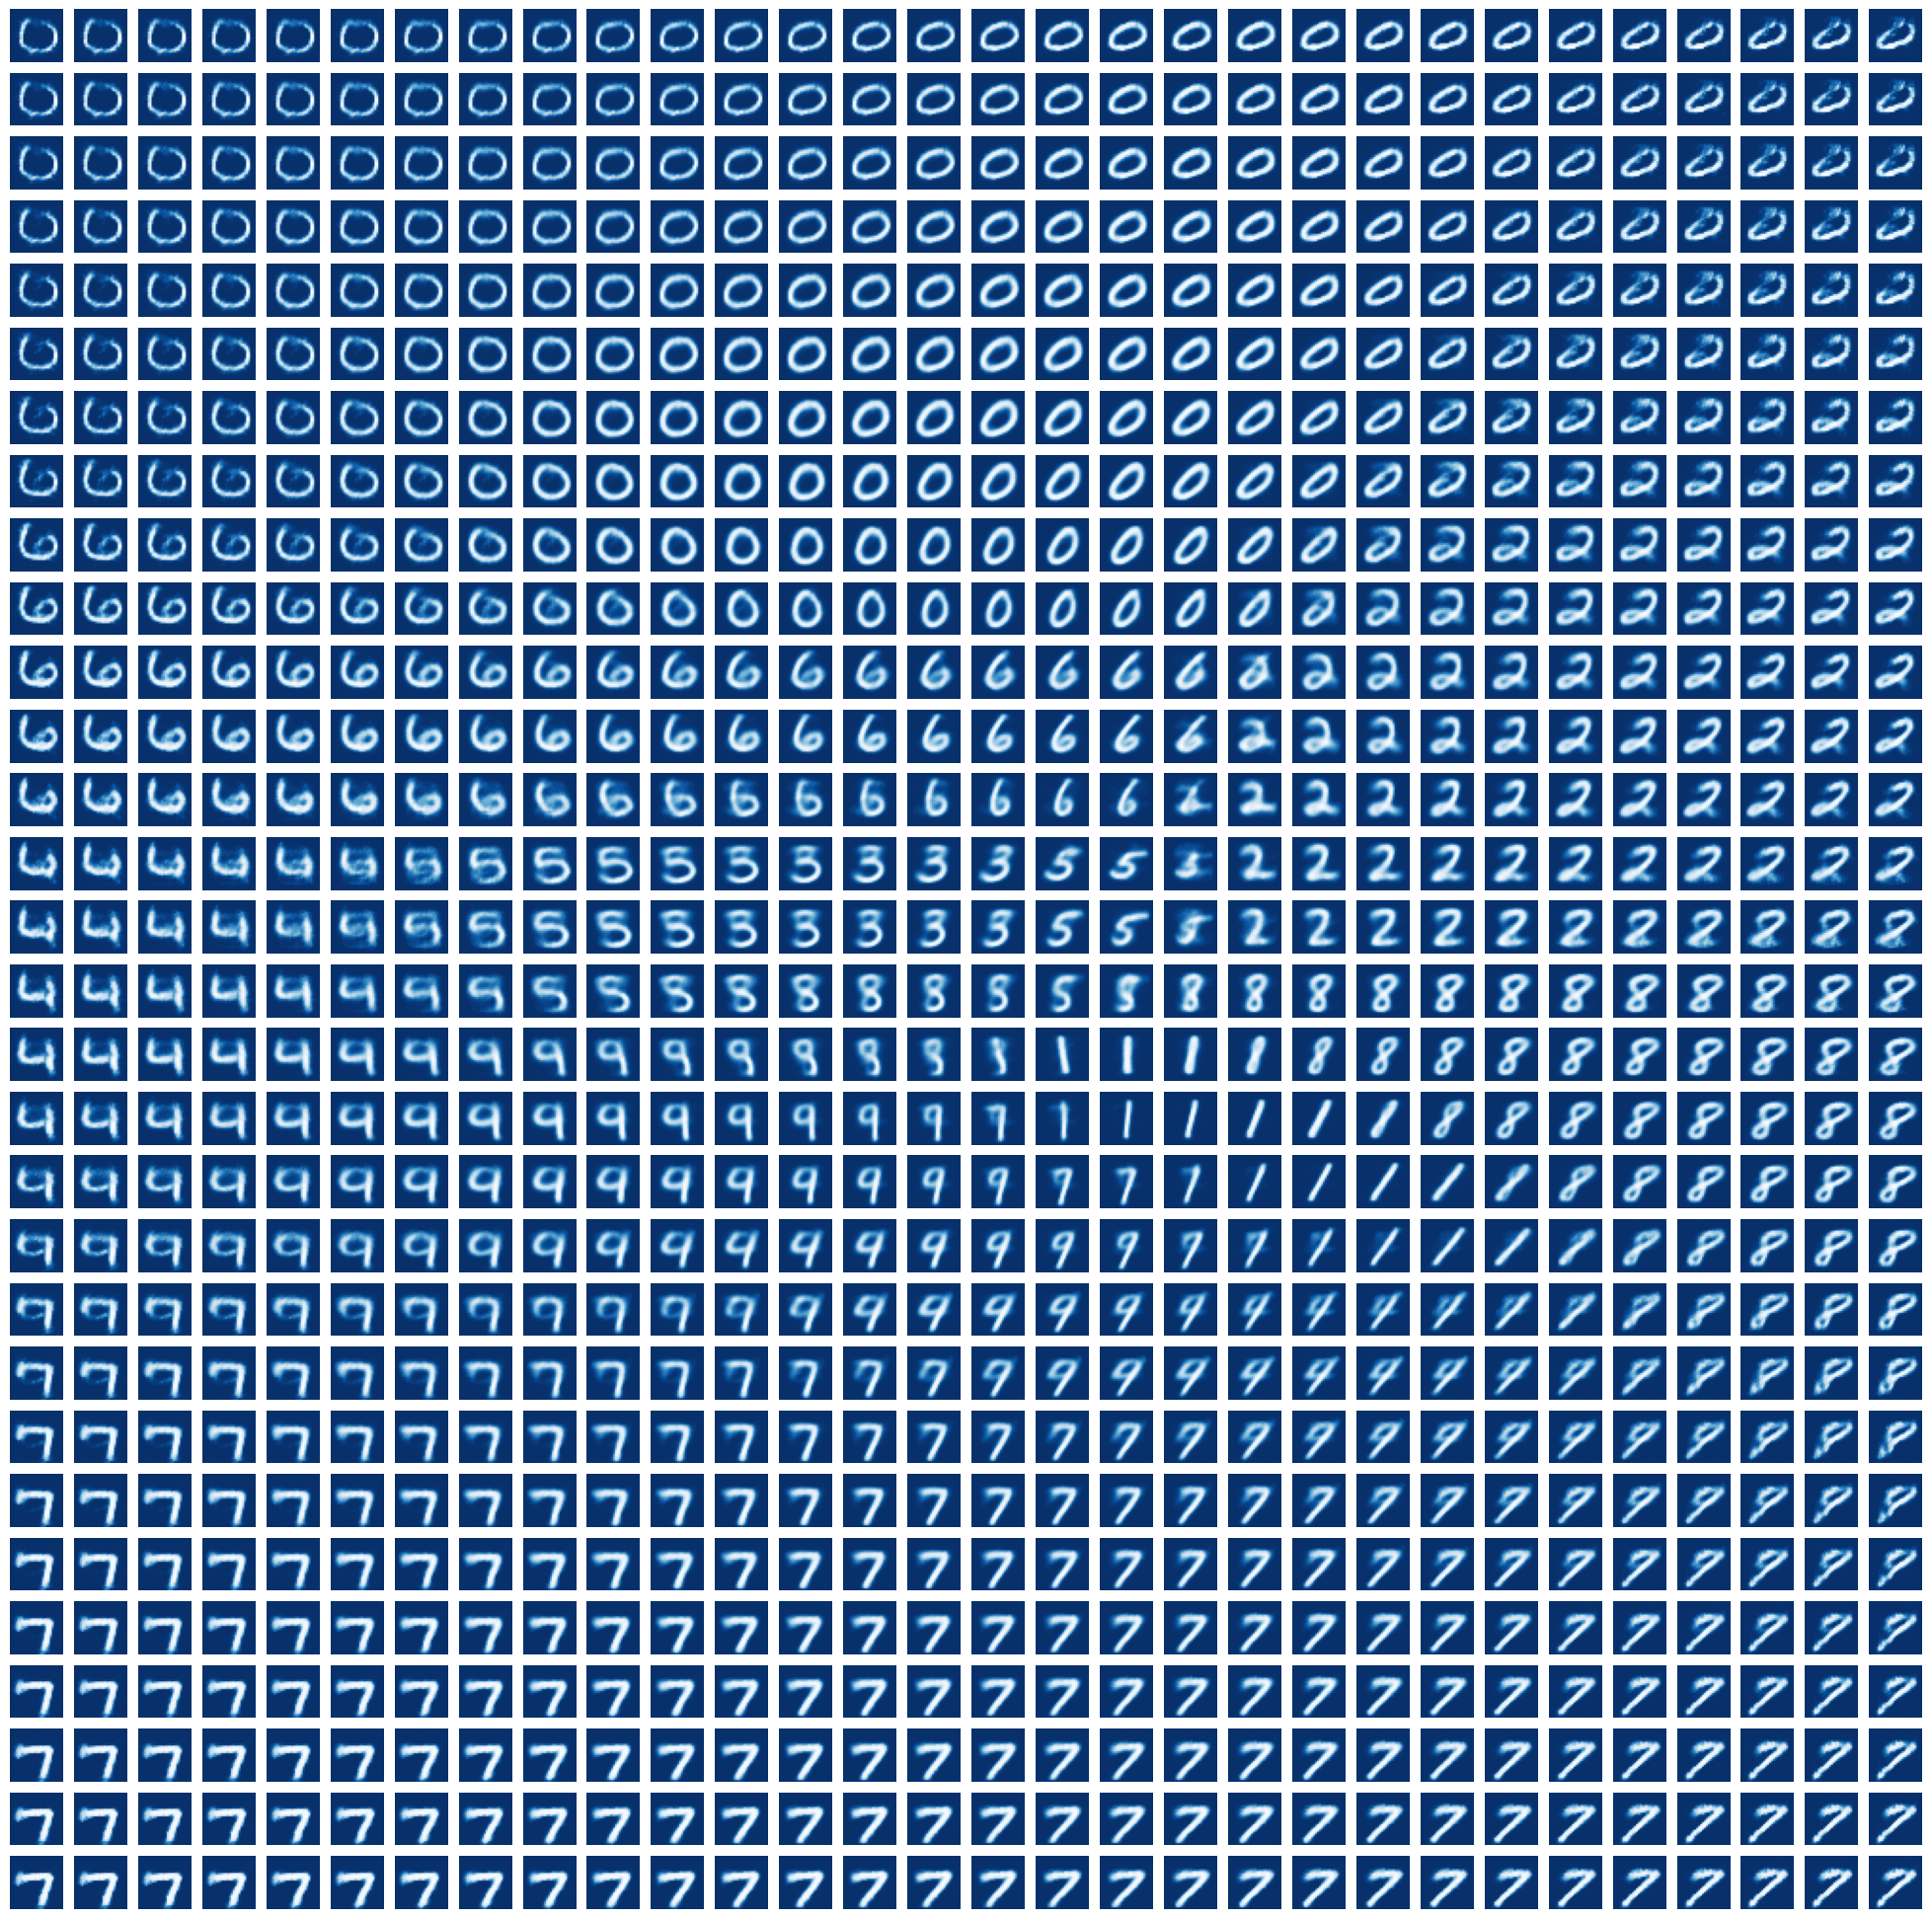

In [54]:
print(f"Showing {n*n} reconstructed images from latent vectors positioned on a regular grid in the latent space")
fig, axs = plt.subplots(n, n, figsize = (25,25))
for r, rows in enumerate(axs):
    for c, ax in enumerate(rows):
        ax.imshow(reconst[r * n + c, :, :, 0], cmap='Blues_r')
        ax.set_axis_off()
# plt.suptitle(f"Showing {n*n} linearly transformed images")
plt.show();

### Reconstruct on grid + real images
Bring images on a grid and latent space classification on the same plot

Prepare to display latent space for the test set

In [55]:
n_to_show = 10_000

if x_test.max() > 1.0: x_test = x_test / 255. 

example_idx = np.random.choice(range(len(x_test)), n_to_show)
example_images = np.reshape(x_test[example_idx], (n_to_show, 28, 28, 1))
example_y = np.squeeze(y_test[example_idx])

m, v = enc.predict(example_images)
embeddings = sampler([m,v])

min_z1 = embeddings[:, 0].numpy().min()
max_z1 = embeddings[:, 0].numpy().max()
min_z2 = embeddings[:, 1].numpy().min()
max_z2 = embeddings[:, 1].numpy().max()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Prepare the grid image generated from a regular grid sampling of the latend space

In [56]:
def make_grid_image(images, n):
    """Place n * n images into a large grid image""" 
    grid_img = np.empty((n * 28, n * 28, 1), dtype='float32')
    
    assert images.shape[0] == n * n, f"{images.shape[0]} images is not compatible with {n}"
    for i in range(n):
        for j in range(n):
            grid_img[i*28:(i+1)*28,j*28:(j+1)*28,:] = images[i*n+j, :, :, :]
    return grid_img

In [57]:
n = 20

z1 = np.reshape(np.linspace(start=min_z1, stop=max_z1, num=n), (n, 1))
z2 = np.reshape(np.linspace(start=min_z2, stop=max_z2, num=n), (n, 1))

zz1, zz2 = np.meshgrid(z1, z2)
zz1_f = np.reshape(zz1, (n*n, 1))
zz2_f = np.reshape(zz2, (n*n, 1))

z_grid = np.concatenate((zz1_f, zz2_f), axis=1)
reconst = dec.predict(z_grid)

grid_reconst = make_grid_image(reconst, n)

reconst.shape, grid_reconst.shape

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step


((400, 28, 28, 1), (560, 560, 1))

In [58]:
cmaps = ['Pastel1', 'Pastel2', 'Paired', 'Accent', 'Dark2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c']
cmap = 'tab10'

# plot_color_bar(cmap)

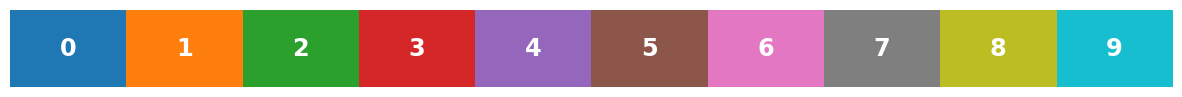

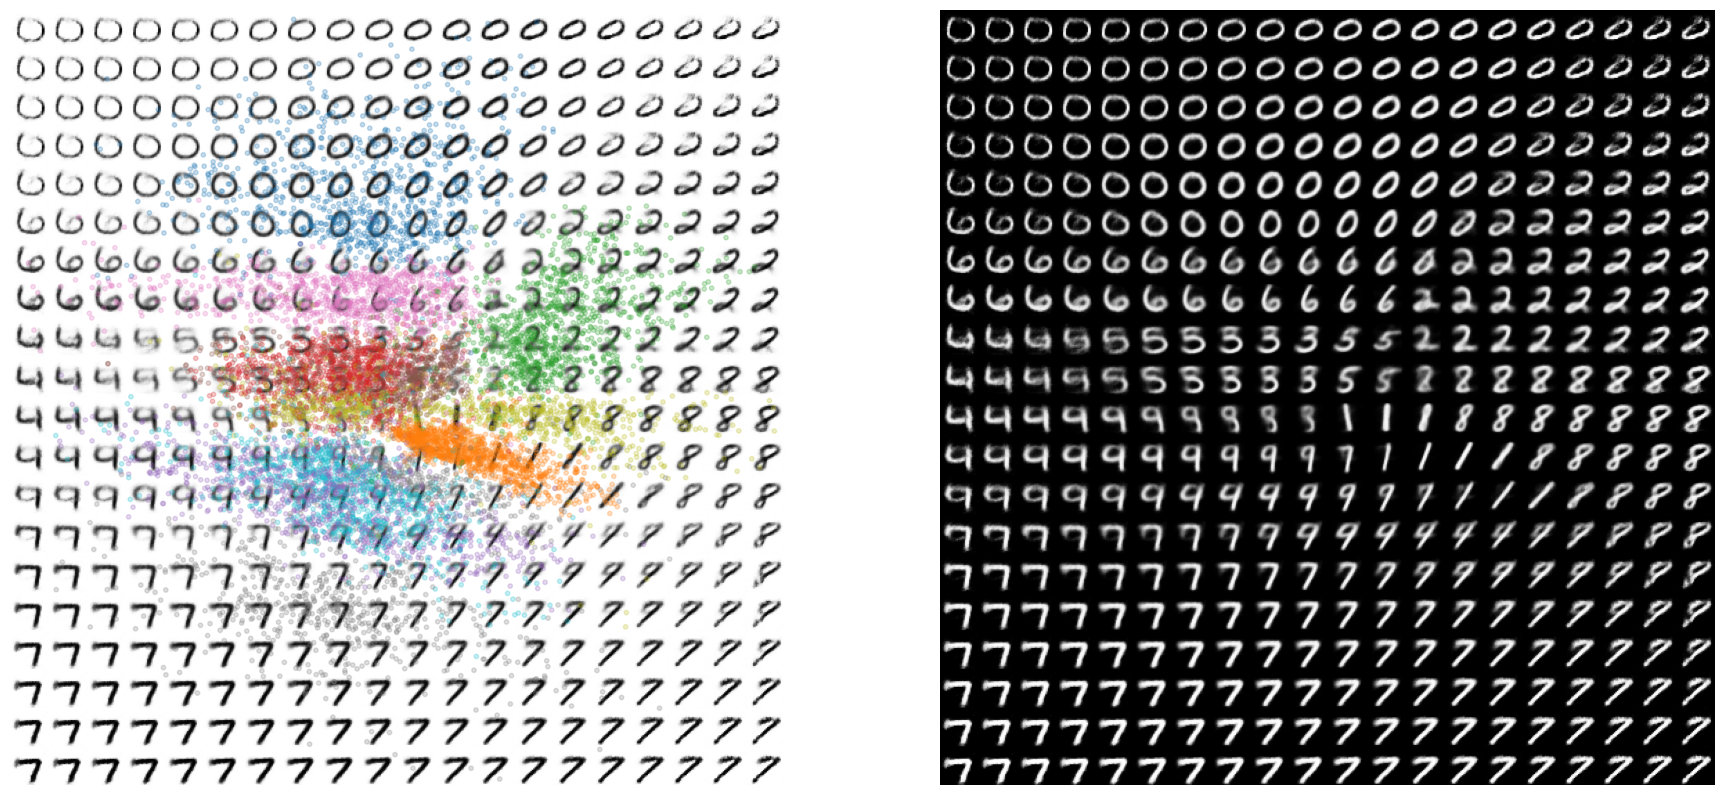

In [61]:
plot_color_bar(cmap)

scaling_z1 = 28 * n / (max_z1 - min_z1)
scaling_z2 = 28 * n / (max_z2 - min_z2)
ctr_z1 = (max_z1-min_z1)/2 * scaling_z1
ctr_z2 = (max_z2-min_z2)/2 * scaling_z2

# print(min_z1, max_z1, min_z2, max_z2)
# print(ctr_z1,scaling_z1, ctr_z2,scaling_z2)
# print(min_z1*scaling_z1+ctr_z1, max_z1*scaling_z1+ctr_z1, min_z2*scaling_z2+ctr_z2, max_z2*scaling_z2+ctr_z2)

_, axs = plt.subplots(nrows=1, ncols=2, figsize=(22,11))
axs[0].scatter(embeddings[:, 0]*scaling_z1+ctr_z1 , embeddings[:, 1]*scaling_z2+ctr_z2, c=example_y, alpha=.25, s=0.5*n, cmap=cmap)
axs[0].imshow(np.reshape(grid_reconst, (n * 28, n * 28)), cmap='Greys')
axs[1].imshow(np.reshape(grid_reconst, (n * 28, n * 28)), cmap='Greys_r')
axs[0].set_axis_off()
axs[1].set_axis_off()
plt.show();

### Reconstruct from test image of a selected single digit

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Min Z1, Z2: [-0.26287702  0.25312078]  Max Z1, Z2: [1.4602834 0.9024061]


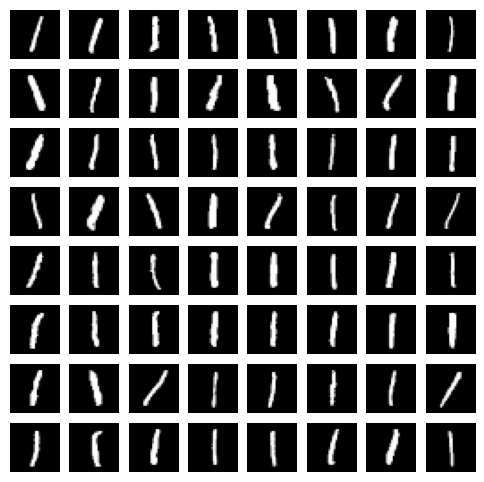

In [62]:
digit = 1
n = 8
figsize = 6

def reconstruct_digit(digit, n=8, figsize=6):
    """Reconstruct image from latent representation of the test images for one digit"""
    idxs = np.reshape(np.argwhere(y_test==digit), [-1])

    bs = x_test[idxs[:n * n], :, :, :]
    means, log_vars = enc.predict(bs)
    latent = sampler([means, log_vars])
    reconst = dec.predict(latent)
    print(f"Min Z1, Z2: {latent.numpy().min(axis=0)}  Max Z1, Z2: {latent.numpy().max(axis=0)}")

    fig, axs = plt.subplots(n, n, figsize = (figsize,figsize))
    for r, rows in enumerate(axs):
        for c, ax in enumerate(rows):
            ax.imshow(bs[r * n + c, :, :, 0], cmap='Greys_r')
            ax.set_axis_off()
    plt.show();

reconstruct_digit(1)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Min Z1, Z2: [-2.8884425 -3.4085472]  Max Z1, Z2: [ 0.82223594 -1.0395284 ]


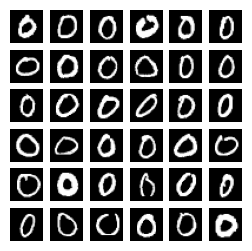

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Min Z1, Z2: [-0.19143453  0.24756262]  Max Z1, Z2: [1.0913618  0.84296125]


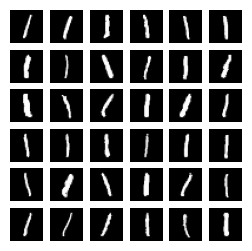

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Min Z1, Z2: [-0.7144568 -1.4287816]  Max Z1, Z2: [2.315987  0.3621749]


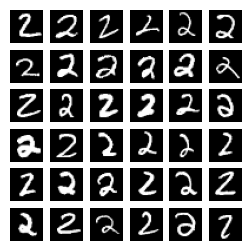

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Min Z1, Z2: [-2.0534973  -0.59221226]  Max Z1, Z2: [0.07600364 0.38954926]


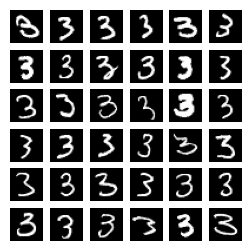

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Min Z1, Z2: [-2.8388038 -1.3976691]  Max Z1, Z2: [0.4707469 1.4448324]


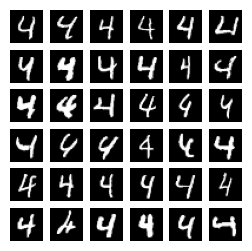

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Min Z1, Z2: [-1.8499388 -0.6815318]  Max Z1, Z2: [0.5741415 0.3262069]


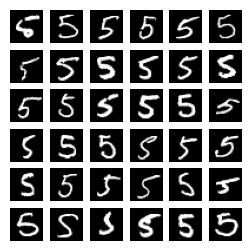

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Min Z1, Z2: [-3.023427  -1.7827634]  Max Z1, Z2: [ 0.63950586 -0.12250644]


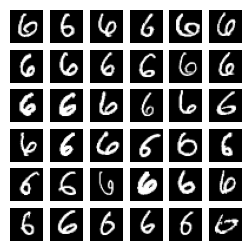

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Min Z1, Z2: [-2.0799184   0.43698448]  Max Z1, Z2: [1.5163379 2.7748024]


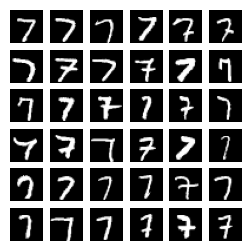

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Min Z1, Z2: [-2.064413  -0.6966702]  Max Z1, Z2: [3.374768  0.7027302]


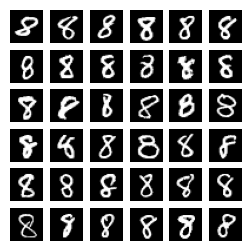

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Min Z1, Z2: [-1.9973024  -0.01332256]  Max Z1, Z2: [1.2234924 2.0294397]


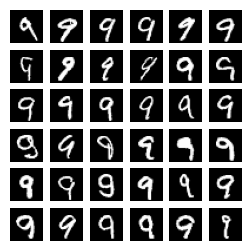

In [63]:
for digit in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    reconstruct_digit(digit, n=6, figsize=3)